# Banking Transaction Analysis Using Python


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset


In [4]:
df = pd.read_csv("bank_transactions_data_2 (1).csv")

In [5]:
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22


In [6]:
print("="*60)
print("First Five Records")
print(df.head())

print("="*60)
print("Dataset Information")
print(df.info())

print("="*60)
print("Statistical Summary")
print(df.describe())


First Five Records
  TransactionID AccountID  TransactionAmount      TransactionDate  \
0      TX000001   AC00128              14.09  2023-04-11 16:29:14   
1      TX000002   AC00455             376.24  2023-06-27 16:44:19   
2      TX000003   AC00019             126.29  2023-07-10 18:16:08   
3      TX000004   AC00070             184.50  2023-05-05 16:32:11   
4      TX000005   AC00411              13.45  2023-10-16 17:51:24   

  TransactionType   Location DeviceID      IP Address MerchantID Channel  \
0           Debit  San Diego  D000380  162.198.218.92       M015     ATM   
1           Debit    Houston  D000051     13.149.61.4       M052     ATM   
2           Debit       Mesa  D000235  215.97.143.157       M009  Online   
3           Debit    Raleigh  D000187  200.13.225.150       M002  Online   
4          Credit    Atlanta  D000308    65.164.3.100       M091  Online   

   CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  \
0           70             Doctor   

##  Missing Values


In [8]:
df.isnull

<bound method DataFrame.isnull of      TransactionID AccountID  TransactionAmount      TransactionDate  \
0         TX000001   AC00128              14.09  2023-04-11 16:29:14   
1         TX000002   AC00455             376.24  2023-06-27 16:44:19   
2         TX000003   AC00019             126.29  2023-07-10 18:16:08   
3         TX000004   AC00070             184.50  2023-05-05 16:32:11   
4         TX000005   AC00411              13.45  2023-10-16 17:51:24   
...            ...       ...                ...                  ...   
2507      TX002508   AC00297             856.21  2023-04-26 17:09:36   
2508      TX002509   AC00322             251.54  2023-03-22 17:36:48   
2509      TX002510   AC00095              28.63  2023-08-21 17:08:50   
2510      TX002511   AC00118             185.97  2023-02-24 16:24:46   
2511      TX002512   AC00009             243.08  2023-02-14 16:21:23   

     TransactionType          Location DeviceID      IP Address MerchantID  \
0              Debit   

## Duplicate Records

In [10]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning


In [11]:
df.drop_duplicates(inplace=True)


## Convert Date Columns

In [12]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

df["PreviousTransactionDate"] = pd.to_datetime(
    df["PreviousTransactionDate"]
)

## Total Transaction Amount


In [13]:
print("="*60)
print("Total Transaction Amount")

print(df["TransactionAmount"].sum())


Total Transaction Amount
747555.5700000001


## Average Transaction

In [14]:
print("="*60)
print("Average Transaction")

print(df["TransactionAmount"].mean())



Average Transaction
297.5937778662421


## Highest Transaction

In [15]:
print("="*60)
print("Highest Transaction")

print(df["TransactionAmount"].max())


Highest Transaction
1919.11


## Lowest Transaction


In [16]:
print("="*60)
print("Lowest Transaction")

print(df["TransactionAmount"].min())


Lowest Transaction
0.26


## Transaction Type Count


In [17]:
print("="*60)
print(df["TransactionType"].value_counts())



TransactionType
Debit     1944
Credit     568
Name: count, dtype: int64


##  Channel Count


In [18]:
print("="*60)
print(df["Channel"].value_counts())


Channel
Branch    868
ATM       833
Online    811
Name: count, dtype: int64


## Customer Occupation


In [19]:
print("="*60)
print(df["CustomerOccupation"].value_counts())


CustomerOccupation
Student     657
Doctor      631
Engineer    625
Retired     599
Name: count, dtype: int64


## Top 10 Highest Transactions

In [20]:
top10 = df.nlargest(10, "TransactionAmount")

print(top10[
    [
        "AccountID",
        "TransactionAmount",
        "TransactionType",
        "Channel"
    ]
])


     AccountID  TransactionAmount TransactionType Channel
653    AC00423            1919.11           Debit     ATM
1438   AC00179            1831.02          Credit  Online
340    AC00107            1830.00           Debit  Online
1634   AC00358            1762.28           Debit     ATM
2414   AC00028            1664.33           Debit  Branch
1247   AC00071            1647.74           Debit     ATM
1788   AC00338            1612.37           Debit     ATM
755    AC00460            1607.55           Debit     ATM
898    AC00083            1531.31           Debit  Online
1984   AC00303            1512.99           Debit  Online


## Average Balance

In [21]:
print("="*60)
print("Average Account Balance")

print(df["AccountBalance"].mean())


Average Account Balance
5114.302965764331


## Correlation

In [22]:
numeric = df.select_dtypes(include=np.number)

print(numeric.corr())


                     TransactionAmount  CustomerAge  TransactionDuration  \
TransactionAmount             1.000000    -0.025616             0.004359   
CustomerAge                  -0.025616     1.000000            -0.017936   
TransactionDuration           0.004359    -0.017936             1.000000   
LoginAttempts                -0.008445     0.007653             0.032639   
AccountBalance               -0.025165     0.319942             0.005577   

                     LoginAttempts  AccountBalance  
TransactionAmount        -0.008445       -0.025165  
CustomerAge               0.007653        0.319942  
TransactionDuration       0.032639        0.005577  
LoginAttempts             1.000000        0.014999  
AccountBalance            0.014999        1.000000  


# Visualizations


In [25]:
import os

# Create output folder if it doesn't exist
os.makedirs("outputs", exist_ok=True)

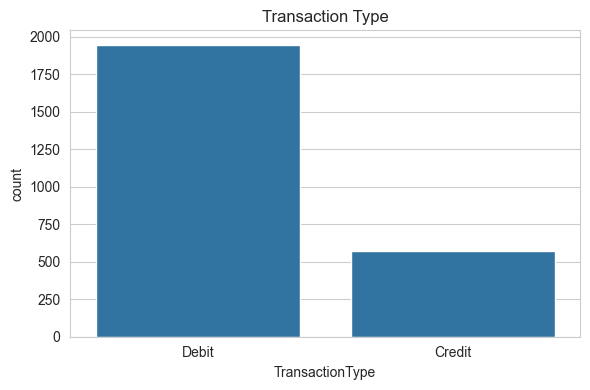

In [26]:
sns.set_style("whitegrid")

# Transaction Type

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="TransactionType"
)

plt.title("Transaction Type")

plt.tight_layout()

plt.savefig("outputs/transaction_type.png")

plt.show()



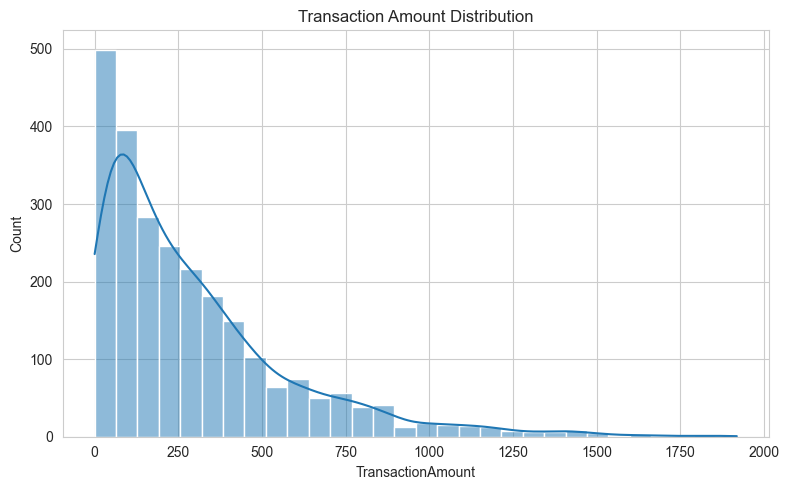

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["TransactionAmount"],
    bins=30,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.tight_layout()

plt.savefig("outputs/amount_distribution.png")

plt.show()


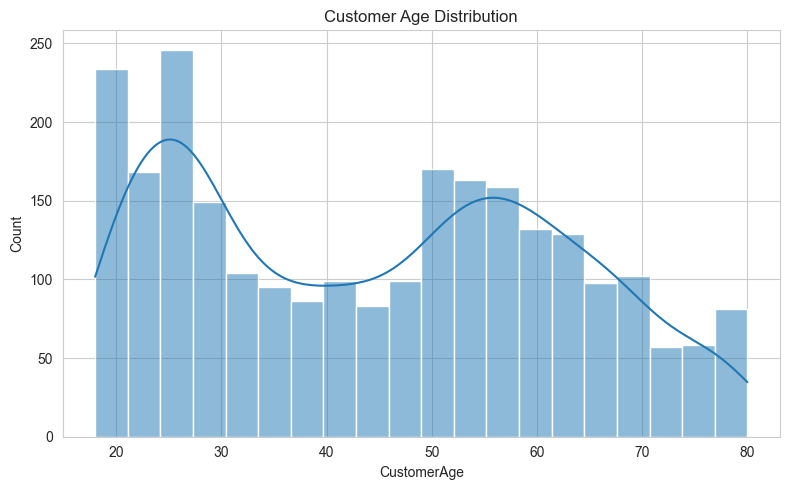

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["CustomerAge"],
    bins=20,
    kde=True
)

plt.title("Customer Age Distribution")

plt.tight_layout()

plt.savefig("outputs/age_distribution.png")

plt.show()


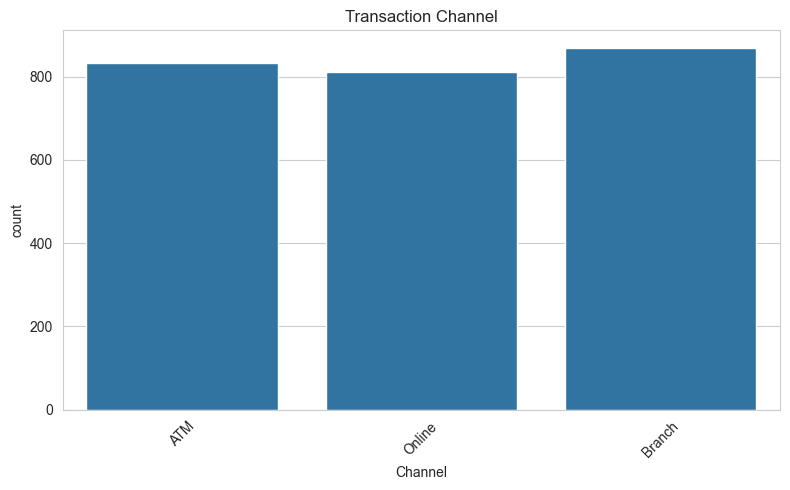

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Channel"
)

plt.xticks(rotation=45)

plt.title("Transaction Channel")

plt.tight_layout()

plt.savefig("outputs/channel_analysis.png")

plt.show()


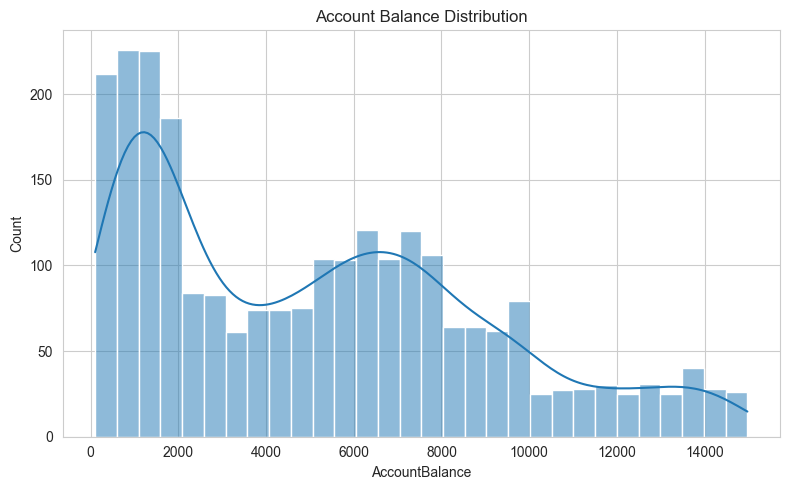

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["AccountBalance"],
    bins=30,
    kde=True
)

plt.title("Account Balance Distribution")

plt.tight_layout()

plt.savefig("outputs/balance_distribution.png")

plt.show()


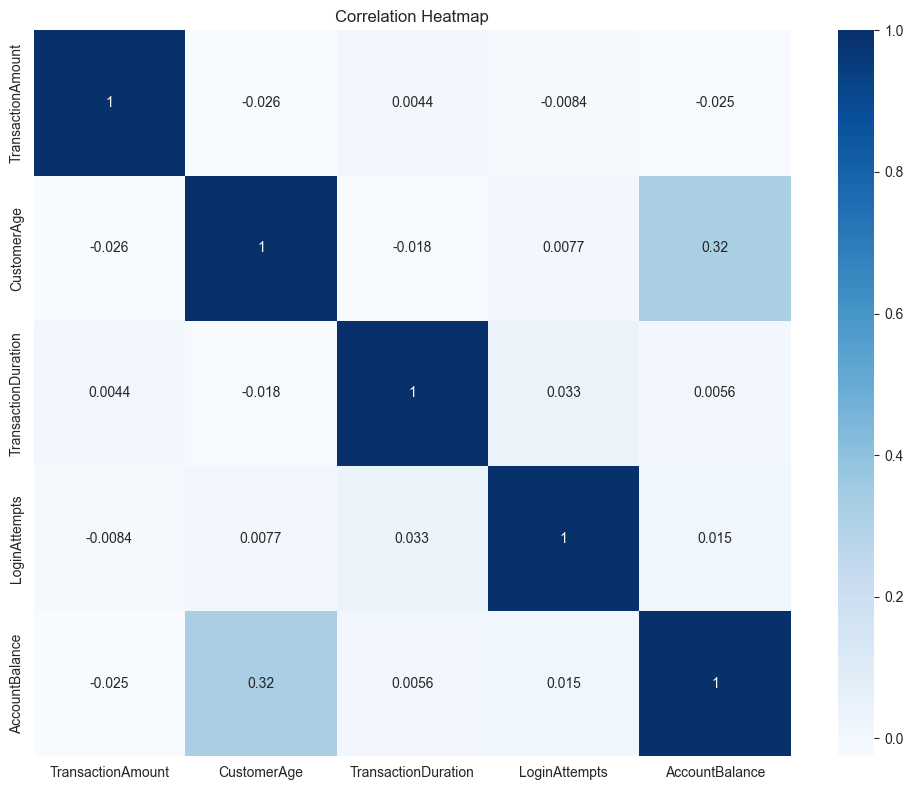

Project Completed Successfully


In [31]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("outputs/correlation_heatmap.png")

plt.show()

print("="*60)
print("Project Completed Successfully")

## Conclusion

This Banking Transaction Analysis project demonstrates how Python can be used to clean, analyze, and visualize financial transaction data effectively. Through Exploratory Data Analysis (EDA), the dataset was examined to identify transaction patterns, customer behavior, account balances, and transaction channels.

The project included data preprocessing, handling missing values and duplicates, statistical analysis, and the creation of informative visualizations such as transaction distributions, customer age analysis, channel usage, and correlation heatmaps. These analyses provide meaningful insights into customer transactions and overall banking operations.

The findings from this project can help financial institutions better understand customer behavior, monitor transaction trends, and support data-driven decision-making. Additionally, this project serves as a strong foundation for advanced applications such as fraud detection, customer segmentation, predictive analytics, and interactive dashboards using Power BI or Streamlit.

Overall, this project showcases practical skills in Python, data analysis, data visualization, and problem-solving, making it an excellent portfolio project for aspiring Data Analysts and Python Developers.